



bgnoise = 2*sig1hr**2*3600*10**(-6)

In [1]:
# pip install astropy matplotlib


In [30]:
from astropy.io import fits

# Open the FITS file
hdul = fits.open("C:/Users/jshld/Downloads/LOPS2PICtarget2.1.0.1-t-fg-c-scv.fits")

# Print summary of HDUs
hdul.info()


Filename: C:/Users/jshld/Downloads/LOPS2PICtarget2.1.0.1-t-fg-c-scv.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   ()      
  1                1 BinTableHDU    350   309787R x 71C   [K, 17A, 28A, D, D, D, D, D, E, D, E, D, D, D, E, D, D, D, D, E, E, I, D, D, D, D, D, D, D, D, D, D, D, D, E, E, E, E, D, D, D, D, D, D, I, E, E, D, D, D, D, D, D, I, I, I, I, I, I, I, I, I, I, I, E, I, I, E, I, I, I]   


In [32]:
data = hdul[1].data      # change index if needed
header = hdul[1].header

for i, hdu in enumerate(hdul):
    print(f"\n===== HEADER FOR HDU {i} =====")
    print(repr(hdu.header))
col65=data.field(64)
hdul.close()


ValueError: I/O operation on closed file

In [48]:
for i in col65:
    print(i)

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [62]:
sig1hr = col65[20000]
bgnoise = 2*sig1hr**2*3600*10**(-6)
print(bgnoise)

134.54560199267584


0.6553144181940975


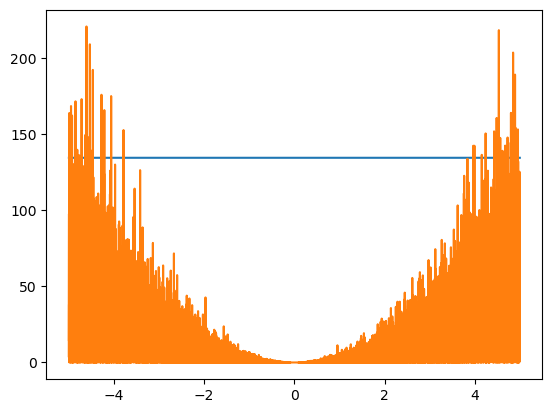

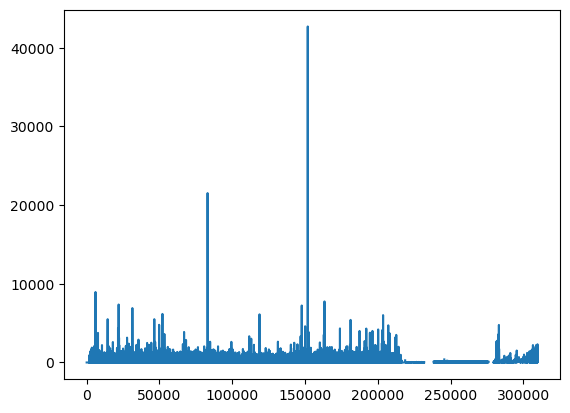

In [84]:
import matplotlib.pyplot as plt
import numpy as np
N=100000
alist=[bgnoise]*N
x=np.linspace(-5,5,N)
plt.plot(x,alist)
import numpy as np

def stochastic(values):
    out=[]
    for i in values:
        out.append(-i*np.log(np.random.uniform(0,1)))
    return out
def parabola(x):
    y=x**2
    return y

ys = stochastic(parabola(np.linspace(-5,5,N)))
plt.plot(x,ys)
plt.show()

plt.plot(range(0,len(col65)),col65)


nan


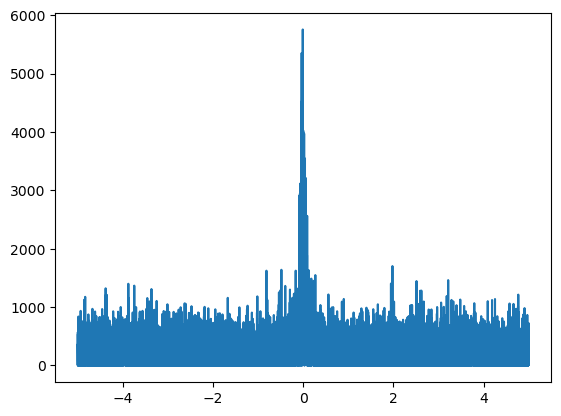

In [117]:
def lorentzian(nu, nu0, H, Gamma):
    return H / (1.0 + 4.0 * (nu - nu0)**2 / Gamma**2)

xvals = np.linspace(-5,5,N)
signal = stochastic(lorentzian(xvals,0,1000,0.1) + [bgnoise]*N) 
print(np.median(col65))
plt.plot(xvals,signal)